<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module5_Part2_STUDENT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 5: Supervised Learning – Classification Basics (Part 2)**

---

#### **Module 5.6: Decision Tree Classifier**

A **Decision Tree Classifier** is a supervised learning model that predicts class labels by **recursively splitting** the dataset into subsets based on feature values. It represents decisions in a **tree structure**, where:
- **Internal nodes** represent decisions based on a specific feature.
- **Branches** represent the outcomes of those decisions.
- **Leaf nodes** represent the final predicted class.

Decision trees are widely used due to their **interpretability**, flexibility with different data types, and role as a foundation for powerful ensemble methods such as **Random Forests** and **Gradient Boosting**.

---

#### **How Decision Trees Work: Step-by-Step**
1. **Select the Best Split Feature**
   - At each node, the algorithm evaluates all features and possible split points.
   - It selects the split that best separates the classes according to a chosen **impurity measure**.

2. **Split the Dataset**
   - Partition the data into subsets based on the chosen feature and threshold.

3. **Repeat Recursively**
   - Apply the same splitting process to each subset until a stopping criterion is met (e.g., maximum depth, minimum samples per node, or pure class nodes).

4. **Assign Class Labels**
   - When a node becomes a leaf, assign the class that is most frequent in that subset.

---

#### **Splitting Criteria**

1. **Gini Impurity**
   - Measures the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the distribution of labels in the node.
   $
   G(t) = 1 - \sum_{i=1}^C p_i^2
   $
   where $(p_i)$ is the proportion of class $(i)$ instances in node $(t)$.

2. **Entropy (Information Gain)**
   - Measures the impurity or disorder in the node.
   $
   H(t) = - \sum_{i=1}^C p_i \log_2(p_i)
   $
   - **Information Gain** for a split $(S)$:
     $
     IG(S) = H(\text{parent}) - \sum_{k=1}^m \frac{N_k}{N} H(\text{child}_k)
     $
     where $(N_k)$ is the number of samples in child $(k)$, and $(N)$ is the number of samples in the parent node.

3. **Other Measures**
   - Classification Error: $(E(t) = 1 - \max_i p_i)$ (less sensitive, rarely used in practice for splitting).

---

#### **Pruning to Prevent Overfitting**
Decision trees can grow very deep, perfectly fitting training data but performing poorly on unseen data. **Pruning** reduces overfitting by:
- **Pre-pruning** (early stopping): Limiting maximum depth, minimum samples per split, or minimum impurity decrease.
- **Post-pruning**: Building the full tree first, then removing branches that do not improve generalization (based on validation set performance).

---

#### **Advantages**
- Highly interpretable and easy to visualize.
- Can handle both numerical and categorical data without scaling.
- Naturally captures non-linear relationships.

#### **Limitations**
- Prone to overfitting without pruning.
- Small changes in data can lead to very different trees (high variance).
- May be biased toward features with many distinct values.

---

#### **Important Considerations**
- Always tune parameters like `max_depth`, `min_samples_split`, and `min_samples_leaf` to improve generalization.
- Use cross-validation to find the optimal complexity.
- Decision trees form the backbone of **ensemble methods** like Random Forests and XGBoost, which overcome many of their weaknesses.

---

#### **Exercise 1: Training a Basic Decision Tree Classifier**

In this exercise, you'll train a simple Decision Tree classifier on the Iris dataset and visualize the resulting decision rules.

**Objective**:  
Understand how a decision tree splits data and makes predictions.

**Instructions**:
1. Load the Iris dataset using `sklearn.datasets.load_iris()`.
2. Split the dataset into training and testing sets (e.g., 80%/20%).
3. Train a `DecisionTreeClassifier` using the Gini impurity as the splitting criterion.
4. Evaluate the model on the test set and report accuracy.
5. Visualize the tree using `plot_tree()` from `sklearn.tree`.
6. Interpret the root decision and the first few levels of the tree.

This exercise helps you understand how a decision tree builds its structure using recursive splits.

---


In [1]:
# Exercise 1: Training a Basic Decision Tree Classifier

# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 2: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Step 3: Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [2]:
# Step 4: Train the Decision Tree Classifier using Gini impurity
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

Test Accuracy: 1.0


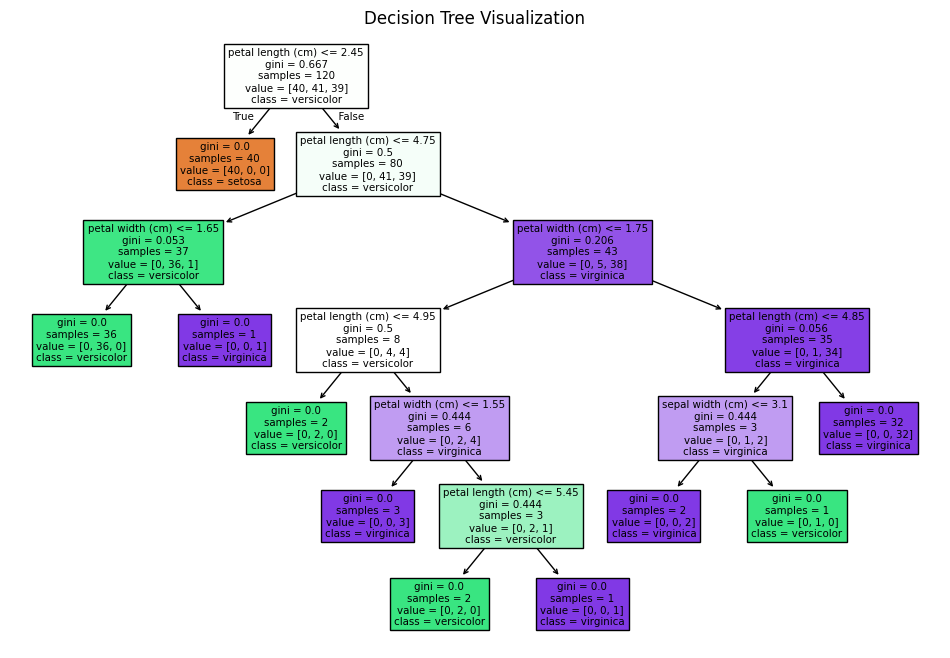

In [3]:
# Step 5: Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Step 6: Visualize the tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we first loaded the Iris dataset and separated the features and target labels. Then we split the data into training and testing sets to make sure we could properly evaluate how well the model performs on unseen data. After that, we trained a Decision Tree Classifier using the Gini impurity measure, which helped the model decide how to split the data at each step. We then made predictions on the test set and calculated the accuracy, which showed how well the model classified the flowers. Visualizing the tree helped me clearly see how the model made decisions, especially how the root node split the data based on the most important feature. Overall, this exercise helped me understand how decision trees are built step by step and how each split contributes to the final prediction. It also showed me how powerful and easy to interpret decision trees can be.


#### **Exercise 2: Visualizing Decision Boundaries of a Decision Tree**

In this exercise, you’ll visualize how a decision tree classifier partitions the feature space, using only two features from the Iris dataset for clarity.

**Objective**:  
Understand how decision trees create decision boundaries by splitting the data based on feature thresholds.

**Instructions**:
1. Load the Iris dataset and select only two features (e.g., petal length and petal width) to simplify visualization.
2. Split the dataset into training and test sets (e.g., 80/20 split).
3. Train a `DecisionTreeClassifier` with a shallow depth (e.g., `max_depth=3`) to observe the decision boundaries clearly.
4. Plot the decision boundary using `matplotlib`:
   - Use a meshgrid to create a background for plotting predictions.
   - Overlay training data points colored by class.
5. Label the axes and add a legend to indicate the species.

This exercise helps illustrate how decision trees separate classes with axis-aligned splits and builds intuition on how tree depth and feature selection affect the model’s complexity.

---


In [4]:
# Exercise 2: Visualizing Decision Boundaries of a Decision Tree

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
iris = load_iris()
X = iris.data[:, [2, 3]]  # Select petal length and petal width
y = iris.target

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Step 3: Train Decision Tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

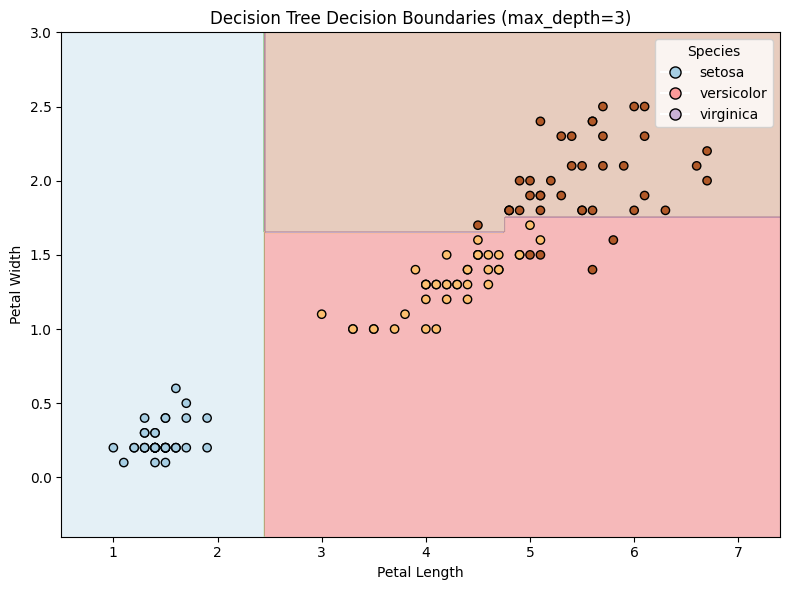

In [7]:
# Step 4: Create a meshgrid for visualization
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 5: Plot decision boundaries and training data
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

# Scatter plot for training data
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                      edgecolor='k', cmap=plt.cm.Paired)

# Custom legend to match target names and colors
from matplotlib.lines import Line2D
unique_classes = np.unique(y_train)
custom_legend = [
    Line2D([0], [0], marker='o', color='w', label=iris.target_names[i],
           markerfacecolor=plt.cm.Paired(i / len(iris.target_names)),
           markeredgecolor='k', markersize=8)
    for i in unique_classes
]

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Decision Tree Decision Boundaries (max_depth=3)')
plt.legend(handles=custom_legend, title="Species")
plt.tight_layout()
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we began by loading the Iris dataset and choosing only petal length and petal width so the visualization would be easier to understand. Then we split the data into training and testing sets to make sure the model was trained properly and evaluated fairly. After that, we trained a decision tree with a small maximum depth, which helped keep the model simple and made the decision boundaries clearer. Using a meshgrid, we created a background that shows how the model predicts different regions of the feature space. We plotted the training data on top of this to compare the actual flower classes with the model’s predictions. From this process, I learned that decision trees create straight, vertical and horizontal splits because they divide the data based on feature thresholds. Overall, this exercise helped me clearly see how tree depth affects model complexity and how decision trees partition the feature space step by step.

#### **Exercise 3: Analyzing Feature Importance in Decision Trees**

In this exercise, you will investigate which features the Decision Tree model considers most important when making predictions. Understanding feature importance helps explain model behavior and guides feature selection.

**Objective**:  
Visualize and interpret feature importance scores from a trained Decision Tree Classifier.

**Instructions**:
1. Load the **Iris dataset** and train a `DecisionTreeClassifier` using all four features.
2. Retrieve the feature importance scores using the `.feature_importances_` attribute.
3. Create a **horizontal bar chart** showing the importance of each feature.
4. Label the axes with feature names and importance scores.
5. Add a title and interpret which features are most influential.

This exercise helps demystify the internal decision-making process of trees and reinforces the link between model decisions and feature characteristics.

---


In [8]:
# Exercise 3: Analyzing Feature Importance in Decision Trees

# Step 1: Load the dataset
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Step 2: Train a Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)


DecisionTreeClassifier(random_state=42)

In [9]:
# Step 3: Retrieve feature importance scores
importances = tree.feature_importances_


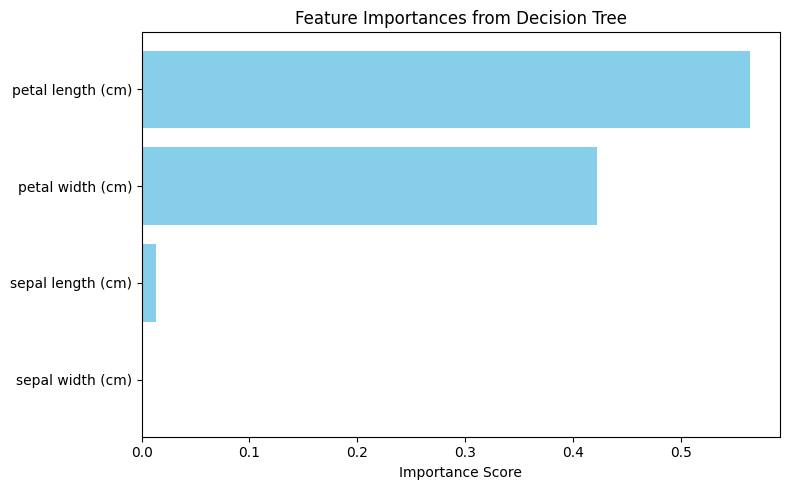

In [10]:
# Step 4: Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Step 5: Plot the feature importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Feature Importances from Decision Tree")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading the full Iris dataset and training a decision tree using all four features. This allowed the model to consider every available measurement when learning how to classify the flowers. After training the model, we used the `.feature_importances_` attribute to see how much each feature contributed to the tree’s decisions. We then organized these importance scores into a DataFrame and created a horizontal bar chart to visualize them clearly. Seeing the bar chart made it much easier to compare which features had the biggest impact on predictions. I learned that not all features contribute equally, and some play a much more important role in classification. Overall, this exercise helped me better understand how decision trees prioritize features and how we can interpret a model beyond just its accuracy.


#### **Exercise 4: Visualizing the Decision Tree Structure**

In this exercise, you will visualize the internal structure of a trained decision tree to understand how it makes classification decisions.

**Objective**:  
Interpret the tree structure to see how features are used for splitting and how decisions lead to class predictions.

**Instructions**:
1. Load the **Iris dataset** and train a `DecisionTreeClassifier` using all features.
2. Use the `plot_tree()` function from `sklearn.tree` to visualize the trained model:
   - Show feature names and class names.
   - Set `filled=True` to color nodes by predicted class.
   - Adjust `max_depth` for better readability (e.g., 3).
3. Display the tree plot using `matplotlib.pyplot`.

This exercise will help you:
- Understand how each split is made based on feature thresholds.
- Identify which features appear most frequently in decision paths.
- Gain insights into how the model makes predictions from root to leaf.

This visualization enhances interpretability and is a powerful tool for explaining classification models to stakeholders or debugging overfitting.

---


In [11]:
# Exercise 4: Visualizing the Decision Tree Structure

# Step 1: Load libraries and dataset
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 2: Train a decision tree classifier
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)


DecisionTreeClassifier(max_depth=3, random_state=42)

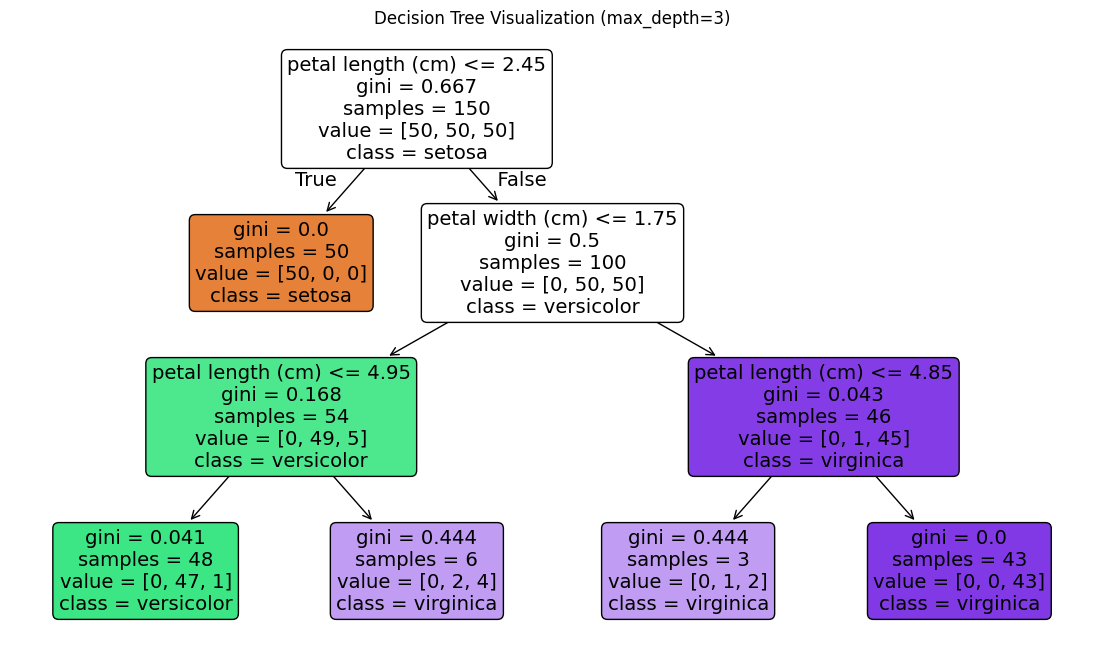

In [12]:
# Step 3: Plot the decision tree
plt.figure(figsize=(14, 8))
plot_tree(tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization (max_depth=3)")
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we loaded the Iris dataset and trained a decision tree using all four features, while limiting the depth to make the structure easier to read. After training the model, we used the plot_tree() function to visualize how the tree makes decisions from the root node down to the leaf nodes. Seeing the tree structure helped me understand how the model chooses specific feature thresholds to split the data step by step. The colored nodes made it clear which class each leaf predicts and how confident the model is at each stage. I also noticed that some features appear more often near the top of the tree, which shows they are more important for classification. Overall, this visualization made the decision-making process much more transparent and easier to interpret. It helped me connect the mathematical idea of splits to a visual representation of how predictions are made.

#### **Exercise 5: Implementing a Decision Tree Classifier from Scratch**

In this exercise, you will implement a basic Decision Tree Classifier **from scratch**, without using libraries like `sklearn`. This helps you understand the internal mechanics of how decision trees work, including splitting, impurity calculation, and recursive tree building.

**Objective**:  
Build a simplified decision tree classifier using Gini impurity and recursive binary splitting.

**Instructions**:
1. Load the Iris dataset and select only two classes (e.g., Setosa vs. Versicolor) to make it a binary classification problem.
2. Implement functions to:
   - Calculate **Gini impurity** for a split.
   - Split the dataset based on a feature and threshold.
   - Find the best split by evaluating all possible features and thresholds.
   - Recursively build the decision tree.
   - Make predictions by traversing the built tree.
3. Train your tree on the training set.
4. Use the model to predict on the test set and evaluate accuracy.
5. Print the structure of the tree (e.g., using indentation to show levels).

This hands-on approach reinforces your understanding of the decision-making process in tree-based models and lays a strong foundation for learning about advanced tree-based algorithms.

---


In [13]:
# Exercise 5: Decision Tree Classifier from Scratch

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from collections import Counter

# Step 1: Load data (only two classes for simplicity)
iris = load_iris()
X = iris.data[iris.target != 2]
y = iris.target[iris.target != 2]

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Step 3: Gini Impurity Calculation
def gini_impurity(y):
    counts = Counter(y)
    impurity = 1
    for label in counts:
        prob_of_lbl = counts[label] / len(y)
        impurity -= prob_of_lbl ** 2
    return impurity


In [15]:
# Step 4: Split data
def split(X, y, feature, threshold):
    left_idx = X[:, feature] <= threshold
    right_idx = X[:, feature] > threshold
    return X[left_idx], y[left_idx], X[right_idx], y[right_idx]

# Step 5: Find best split
def best_split(X, y):
    best_feature, best_thresh, best_gini = None, None, float("inf")
    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            X_left, y_left, X_right, y_right = split(X, y, feature, threshold)
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            gini = (len(y_left) * gini_impurity(y_left) + len(y_right) * gini_impurity(y_right)) / len(y)
            if gini < best_gini:
                best_gini = gini
                best_feature = feature
                best_thresh = threshold
    return best_feature, best_thresh


In [16]:
# Step 6: Build tree recursively
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5):
    if len(set(y)) == 1 or depth >= max_depth:
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    feature, threshold = best_split(X, y)
    if feature is None:
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    X_left, y_left, X_right, y_right = split(X, y, feature, threshold)
    left_node = build_tree(X_left, y_left, depth + 1, max_depth)
    right_node = build_tree(X_right, y_right, depth + 1, max_depth)
    return Node(feature, threshold, left_node, right_node)


In [17]:
# Step 7: Prediction function
def predict(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

# Step 8: Evaluate accuracy
def predict_batch(tree, X):
    return np.array([predict(tree, x) for x in X])

tree = build_tree(X_train, y_train)
y_pred = predict_batch(tree, X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")

# Step 9: Print tree structure
def print_tree(node, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Class {node.value}")
    else:
        print(f"{indent}Feature {node.feature} <= {node.threshold}")
        print_tree(node.left, depth + 1)
        print_tree(node.right, depth + 1)

print_tree(tree)

Accuracy: 1.00
Feature 2 <= 1.9
  Leaf: Class 0
  Leaf: Class 1


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we built a decision tree from scratch, which really helped me understand how the algorithm works behind the scenes. We first simplified the Iris dataset to only two classes so it would be easier to focus on the logic of binary classification. Then we implemented the Gini impurity formula to measure how mixed the classes are after a split. After that, we wrote functions to test different features and thresholds to find the best possible split at each step. Using recursion, we built the tree layer by layer until it reached a stopping condition. We also created a prediction function to move through the tree and classify new data points. Finally, evaluating the model’s accuracy and printing the tree structure helped me clearly see how a single feature and threshold could perfectly separate the two classes. Overall, this exercise gave me a much deeper understanding of how decision trees actually calculate splits and make predictions.

#### **Module 5.7: Naive Bayes Classifier**

The **Naive Bayes (NB)** classifier is a probabilistic model grounded in **Bayes’ theorem**. It assumes that features are **conditionally independent** given the class label. Despite this “naive” assumption, NB is remarkably effective in many real applications—especially **text classification**—because it is fast, scalable, and robust in **high‑dimensional** spaces.

---

#### **Why Naive Bayes Matters**
Naive Bayes provides a simple, interpretable baseline with strong performance for sparse, high‑dimensional data (e.g., bag‑of‑words text). It trains quickly, requires little data, and yields probabilistic outputs that can be converted into class predictions or used for ranking.

---

#### **Bayes’ Theorem and the Naive Assumption**
For a class $( y \in \mathcal{Y} )$ and feature vector $( \mathbf{x} = (x_1,\dots,x_d) )$,
$
P(y \mid \mathbf{x}) \propto P(y)\,P(\mathbf{x}\mid y).
$

The **naive conditional independence** assumption factorizes the class‑conditional likelihood:
$
P(\mathbf{x}\mid y) = \prod_{j=1}^{d} P(x_j \mid y).
$

Thus, the **MAP decision rule** becomes
$
\hat{y} \;=\; \arg\max_{y \in \mathcal{Y}} \; P(y)\,\prod_{j=1}^{d} P(x_j \mid y).
$

In practice we compute in **log‑space** to avoid underflow:
$
\hat{y} \;=\; \arg\max_{y} \left\{ \log P(y) \;+\; \sum_{j=1}^{d} \log P(x_j \mid y) \right\}.
$

---

#### **Model Variants and Likelihoods**

1. **Gaussian Naive Bayes (continuous features)**  
   Assumes each feature is Gaussian within a class:


   $
   x_j \mid y \sim \mathcal{N}(\mu_{jy}, \sigma_{jy}^2),
   \quad
   P(x_j \mid y) = \frac{1}{\sqrt{2\pi}\sigma_{jy}}
   \exp\!\left(-\frac{(x_j-\mu_{jy})^2}{2\sigma_{jy}^2}\right).
   $

3. **Multinomial Naive Bayes (counts, e.g., word counts)**  
   Suitable for **term‑frequency** features. With vocabulary size $(|V|)$ and class‑specific parameters $(\theta_{jy})$ (probability of term $(j)$ in class $(y)$):


   $
   P(\mathbf{x}\mid y) \propto \prod_{j=1}^{d} \theta_{jy}^{\,x_j},
   \qquad
   \theta_{jy} = \frac{N_{jy} + \alpha}{\sum_{k=1}^{d} N_{ky} + \alpha |V|}.
   $


   Here $(N_{jy})$ is the total count of feature $(j)$ in class $(y)$, and $(\alpha>0)$ is **Laplace/ Lidstone smoothing**.

4. **Bernoulli Naive Bayes (binary indicators)**  
   Suitable for **presence/absence** features:


   $
   P(x_j \mid y) = \theta_{jy}^{\,x_j} (1-\theta_{jy})^{\,1-x_j},
   \qquad
   \theta_{jy} = \frac{N_{jy} + \alpha}{N_y + 2\alpha},
   $


   where $(N_{jy})$ counts documents of class $(y)$ where feature $(j)$ appears, and $(N_y)$ is the number of class‑$(y)$ documents.

---

#### **Training and Prediction: Step‑by‑Step (Conceptual)**
1. **Estimate priors** $(P(y))$ from class frequencies (optionally smoothed).
2. **Estimate likelihood parameters** $(P(x_j \mid y))$ using the appropriate variant:
   - Gaussian: estimate $(\mu_{jy}, \sigma_{jy}^2)$ per feature and class.
   - Multinomial: estimate $(\theta_{jy})$ with smoothing $(\alpha)$.
   - Bernoulli: estimate $(\theta_{jy})$ with smoothing $(\alpha)$.
3. **Predict** $(\hat{y})$ for a new $(\mathbf{x})$ via the log‑posterior score:

   $(\log P(y) + \sum_j \log P(x_j \mid y))$; choose the class with the largest score.

---

#### **Smoothing and Zero‑Probability Problem**
Without smoothing, unseen feature–class pairs yield $(P(x_j \mid y)=0)$ and zero out the entire product. **Laplace/Lidstone smoothing** ($(\alpha > 0)$) avoids this:
- Multinomial: $(\theta_{jy} = \frac{N_{jy}+\alpha}{\sum_k N_{ky}+\alpha|V|})$.
- Bernoulli: adds pseudo‑counts to both presence and absence.

---

#### **Strengths**
- **Fast and scalable** (training and prediction).
- **Works well in high dimensions** (e.g., text with thousands of features).
- **Simple, interpretable probabilistic framework**.
- Robust when many features are **irrelevant** (they tend to cancel out).

#### **Limitations**
- **Feature independence assumption** is often violated; correlated features can bias likelihoods.
- **Probability calibration** can be poor; raw posteriors may need **calibration** (e.g., Platt scaling, isotonic regression).
- Multinomial NB expects **counts**; TF‑IDF can work but changes likelihood interpretation.
- Sensitive to **class‑prior imbalance** if not handled appropriately.

---

#### **Important Considerations**
- Choose the variant that matches your feature type (Gaussian for continuous, Multinomial for counts, Bernoulli for binary presence/absence).
- Apply **smoothing** to handle unseen features and improve robustness.
- Consider **feature selection** or **decorrelation** if strong dependencies exist.
- For imbalanced data, adjust class priors or decision thresholds and evaluate with metrics beyond accuracy (e.g., precision/recall, ROC‑AUC).

---



#### **Exercise 6: Gaussian Naive Bayes on Iris Dataset**

In this exercise, you'll apply the **Gaussian Naive Bayes** classifier to the Iris dataset. This variant assumes that continuous features follow a normal distribution, making it well-suited for datasets like Iris where features are real-valued.

**Objective**:  
Train and evaluate a Gaussian Naive Bayes model on the Iris dataset.

**Instructions**:
1. Load the Iris dataset using `sklearn.datasets.load_iris()`.
2. Split the dataset into training and testing sets (e.g., 80/20 split).
3. Train a `GaussianNB` classifier from `sklearn.naive_bayes` using the training data.
4. Predict class labels on the test data.
5. Evaluate the model using accuracy, confusion matrix, and classification report.
6. (Optional) Visualize decision boundaries using PCA or 2D feature projections.

This exercise helps you understand how Naive Bayes handles continuous features and introduces the basic workflow for training a probabilistic classifier.

---


In [18]:
# Exercise 6: Gaussian Naive Bayes on Iris Dataset

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
# Step 3: Train the Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = gnb.predict(X_test)


Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


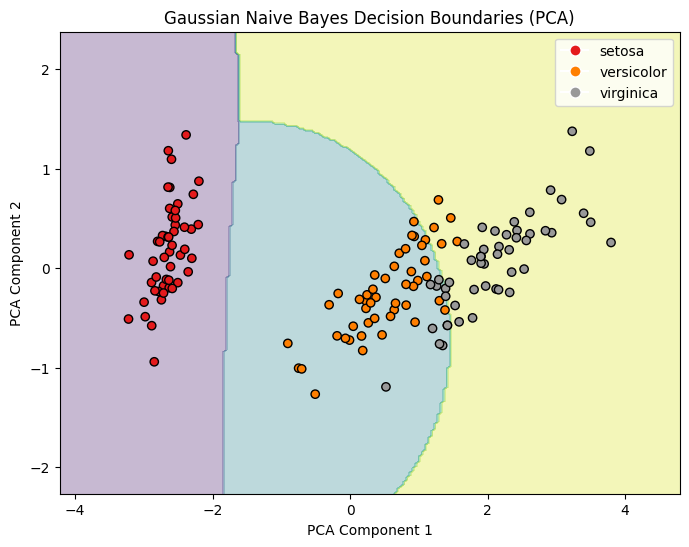

In [20]:
# Step 5: Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=target_names)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

# Step 6 (Optional): Visualize decision boundaries using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca = train_test_split(X_pca, test_size=0.2, random_state=42, stratify=y)

gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = gnb_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', cmap=plt.cm.Set1)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian Naive Bayes Decision Boundaries (PCA)")
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', label=name,
                            markerfacecolor=plt.cm.Set1(i / 2), markersize=8)
                 for i, name in enumerate(target_names)]
plt.legend(handles=legend_labels)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading the Iris dataset and splitting it into training and testing sets to make sure our evaluation was fair. Then we trained a Gaussian Naive Bayes model, which assumes that the features follow a normal distribution within each class. After making predictions on the test set, we evaluated the model using accuracy, a confusion matrix, and a classification report to better understand its performance. The results showed high accuracy, with only one small misclassification, which helped me see that Naive Bayes can perform very well even with its strong independence assumption. The confusion matrix made it easier to identify exactly where the model made mistakes. We also visualized the decision boundaries using PCA, which helped me see how the model separates the classes in a lower-dimensional space. Overall, this exercise helped me understand how probabilistic classifiers work and how to evaluate them beyond just looking at accuracy.

#### **Exercise 7: Multinomial Naive Bayes for Text Classification**

In this exercise, you'll apply the **Multinomial Naive Bayes** classifier to a text classification problem, commonly used in spam detection, news categorization, and sentiment analysis.

**Objective**:  
Use Multinomial Naive Bayes to classify text documents into categories based on word frequency features.

**Instructions**:
1. Load the **20 Newsgroups dataset** from `sklearn.datasets`, selecting a few categories for faster execution (e.g., `['comp.graphics', 'sci.space', 'rec.sport.hockey']`).
2. Preprocess the text using `CountVectorizer` to extract token counts (bag-of-words model).
3. Split the dataset into training and test sets (80/20 split).
4. Train a `MultinomialNB` classifier on the training data.
5. Evaluate the model using accuracy and classification report on the test set.
6. Print the top predictive words per class using the learned feature log probabilities.

This exercise helps you understand how Naive Bayes handles high-dimensional sparse data and how it performs well on natural language classification tasks.

---  


In [21]:
# Exercise 7: Multinomial Naive Bayes with Progress Bar

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Step 1: Load a smaller subset for faster execution
categories = ['comp.graphics', 'sci.space', 'rec.sport.hockey']
newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

# Limit to first 1500 documents for speed
data_sample = newsgroups.data[:1500]
target_sample = newsgroups.target[:1500]


In [22]:
# Step 2: Convert text to bag-of-words
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(data_sample)
y = target_sample

In [23]:
# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Train the Multinomial Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)


MultinomialNB()

In [24]:
# Step 5: Predict and evaluate
y_pred = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

# Step 6: Show top predictive words
feature_names = np.array(vectorizer.get_feature_names_out())
for i, class_label in enumerate(nb.classes_):
    top10 = np.argsort(nb.feature_log_prob_[i])[-10:]
    print(f"Top words for class {newsgroups.target_names[class_label]}:")
    print(", ".join(feature_names[top10]))
    print()

Accuracy: 0.8833333333333333
                  precision    recall  f1-score   support

   comp.graphics       0.86      0.89      0.87        96
rec.sport.hockey       0.92      0.92      0.92       105
       sci.space       0.86      0.84      0.85        99

        accuracy                           0.88       300
       macro avg       0.88      0.88      0.88       300
    weighted avg       0.88      0.88      0.88       300

Top words for class comp.graphics:
pub, software, files, file, ftp, use, data, edu, graphics, image

Top words for class rec.sport.hockey:
11, 12, play, season, hockey, 10, 25, 55, game, team

Top words for class sci.space:
launch, just, lunar, shuttle, data, like, time, earth, nasa, space



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we worked with a subset of the 20 Newsgroups dataset to focus on three categories and make the task manageable. We started by converting the text into a bag-of-words representation using CountVectorizer, which turned the documents into numerical features based on word counts. After splitting the data into training and test sets, we trained a Multinomial Naive Bayes classifier, which is well-suited for this kind of high-dimensional, sparse data. Evaluating the model with accuracy and a classification report showed that it performed well, with most documents correctly classified. We also explored the top predictive words for each class, which helped us understand what features the model relied on to make decisions. Seeing words like “graphics,” “hockey,” and “nasa” appear for their respective categories made it clear how Naive Bayes links specific terms to classes. Overall, this exercise reinforced how probabilistic models can handle text data efficiently and provided insight into interpreting model predictions in a tangible way.

#### **Exercise 8: Gaussian Naive Bayes on Wine Quality Dataset**

In this exercise, you'll apply the Gaussian Naive Bayes classifier to predict wine quality categories using numeric physicochemical properties of the wine.

**Objective**:  
Learn to use Gaussian Naive Bayes for multi-class classification on numeric data.

**Instructions**:
1. Load the **Wine Quality** dataset (e.g., from `sklearn.datasets` or UCI).
2. Inspect the dataset to understand its features (e.g., acidity, alcohol, sugar).
3. Convert the quality score into categories (e.g., low, medium, high).
4. Normalize or scale the features if needed.
5. Split the dataset into training and test sets (80/20 split).
6. Train a `GaussianNB` classifier on the training data.
7. Evaluate the model using accuracy, classification report, and confusion matrix.
8. (Optional) Plot the decision boundaries using PCA-reduced components.

This exercise highlights how Naive Bayes handles continuous features using Gaussian distributions and is well-suited for numeric data.

---

In [25]:
# Exercise 8: Gaussian Naive Bayes on Wine Dataset (sklearn version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns

# Step 1: Load the wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
target_names = wine.target_names

# Step 2: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
# Step 4: Train Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


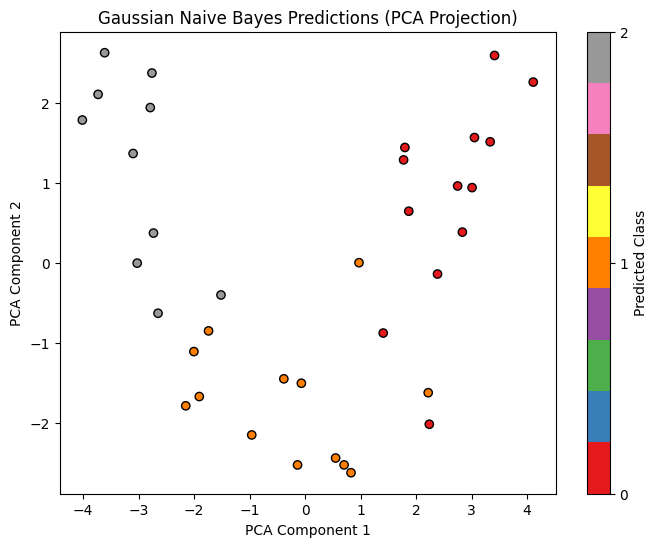

In [27]:
# Step 5: Predict and evaluate
y_pred = gnb.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=target_names)
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 6: Print evaluation results
print("Accuracy:", accuracy)
print(report)
print("Confusion Matrix:\n", conf_matrix)

# Step 7 (Optional): Visualize using PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='Set1', edgecolor='k')
plt.title("Gaussian Naive Bayes Predictions (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, ticks=[0, 1, 2], label='Predicted Class')
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we worked with the Wine dataset to predict wine classes based on their chemical properties. We started by exploring the features and preparing the data, then scaled the numeric values to make the model training more stable. After splitting the dataset into training and test sets, we trained a Gaussian Naive Bayes classifier, which assumes that each feature follows a normal distribution within each class. Evaluating the model with accuracy, a classification report, and a confusion matrix showed that it performed very well, correctly predicting most wine classes. We also used PCA to reduce the features to two dimensions and visualized the predictions, which helped us see how the model separates classes in a simplified view. This exercise reinforced how Naive Bayes handles continuous numeric data efficiently and highlighted the importance of preprocessing and feature scaling. Overall, it gave me a clearer understanding of how probabilistic models make predictions and how to interpret their results.

#### **Exercise 9: Binary Text Classification using Bernoulli Naive Bayes**

In this exercise, you'll explore a different variant of the Naive Bayes classifier — the **Bernoulli Naive Bayes** — which is particularly well-suited for binary feature data, such as word presence/absence in documents.

**Objective**:  
Learn how to apply Bernoulli Naive Bayes for text classification using binary word occurrence features.

**Instructions**:
1. Load a subset of the 20 Newsgroups dataset with categories like `['alt.atheism', 'soc.religion.christian']`.
2. Convert the text documents to binary feature vectors using `CountVectorizer(binary=True)`.
3. Split the data into training and testing sets.
4. Train a `BernoulliNB` model on the binary data.
5. Evaluate its performance using accuracy, confusion matrix, and classification report.
6. Compare and contrast the output with results from a Multinomial Naive Bayes classifier.

This exercise highlights how the **Bernoulli model handles binary input** (presence vs. absence of words), making it ideal for specific types of document classification tasks. It also helps deepen your understanding of how model assumptions influence performance.

---


In [28]:
# Exercise 9: Binary Text Classification using Bernoulli Naive Bayes

# Step 1: Import necessary libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load a subset of the 20 Newsgroups dataset
categories = ['alt.atheism', 'soc.religion.christian']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))


In [29]:
# Step 3: Convert text to binary features (word presence)
vectorizer = CountVectorizer(binary=True, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)
y = newsgroups.target


In [30]:
# Step 4: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Step 5: Train a Bernoulli Naive Bayes classifier
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

BernoulliNB()

BernoulliNB Accuracy: 0.7722222222222223
                        precision    recall  f1-score   support

           alt.atheism       0.68      0.91      0.78       159
soc.religion.christian       0.90      0.67      0.77       201

              accuracy                           0.77       360
             macro avg       0.79      0.79      0.77       360
          weighted avg       0.80      0.77      0.77       360



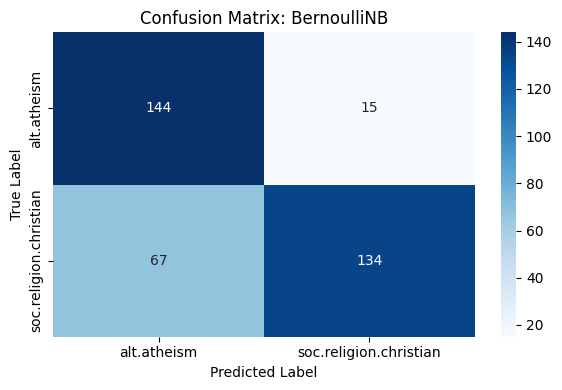

In [32]:
# Step 6: Make predictions and evaluate
y_pred = bnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=newsgroups.target_names)

print("BernoulliNB Accuracy:", accuracy)
print(report)

# Step 7 (Optional): Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.title("Confusion Matrix: BernoulliNB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we explored how to classify text using the Bernoulli Naive Bayes model, which focuses on the presence or absence of words rather than their counts. We started by selecting two categories from the 20 Newsgroups dataset and converting the text into binary features, showing whether a word appears in a document or not. After splitting the data into training and test sets, we trained the BernoulliNB classifier and evaluated its performance using accuracy, a classification report, and a confusion matrix. The model achieved decent accuracy, and the confusion matrix helped us see which class the model predicted more confidently. Compared to Multinomial Naive Bayes, we noticed that BernoulliNB behaves differently because it only considers word presence rather than frequency. This exercise helped me understand how feature representation affects model performance and why choosing the right Naive Bayes variant matters for different types of data. Overall, it gave a clear picture of how probabilistic models can work with binary text features and the importance of analyzing predictions carefully.

#### **Exercise 10: Naive Bayes Classifier from Scratch on Numeric Data**

In this exercise, you'll build a simple **Gaussian Naive Bayes classifier from scratch** using the Wine dataset. This will help you understand how the algorithm computes probabilities and makes predictions based on the Gaussian distribution of feature values.

**Objective**:  
Implement and evaluate a custom Naive Bayes classifier on numeric data using fundamental principles.

**Instructions**:
1. Load the **Wine dataset** from `sklearn.datasets`.
2. Split the data into training and test sets.
3. For each feature and class:
   - Compute the **mean** and **variance** of the feature values.
4. Implement the **Gaussian probability density function** to calculate likelihoods.
5. Compute **prior probabilities** for each class.
6. For each test instance:
   - Calculate the **posterior probability** for each class.
   - Assign the class with the **highest posterior**.
7. Evaluate the accuracy of your custom model using test data.
8. (Optional) Compare your results with `GaussianNB` from scikit-learn.

This exercise deepens your understanding of how Naive Bayes works internally and strengthens your skills in probability-based modeling.

---


In [33]:
# Exercise 10: Naive Bayes Classifier from Scratch on Numeric Data

import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Load the Wine dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
classes = np.unique(y)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
# Step 3: Compute priors
priors = {}
for cls in classes:
    priors[cls] = np.mean(y_train == cls)


In [35]:
# Step 4: Compute mean and variance for each feature per class
mean_var = {}
for cls in classes:
    X_cls = X_train[y_train == cls]
    mean_var[cls] = {
        "mean": X_cls.mean(),
        "var": X_cls.var() + 1e-9  # to avoid division by zero
    }


In [36]:
# Step 5: Define Gaussian PDF
def gaussian_pdf(x, mean, var):
    coef = 1.0 / np.sqrt(2 * np.pi * var)
    exp = np.exp(-(x - mean) ** 2 / (2 * var))
    return coef * exp


In [37]:
# Step 6: Predict function
def predict(X):
    y_pred = []
    for _, x in X.iterrows():
        posteriors = {}
        for cls in classes:
            prior = np.log(priors[cls])
            likelihood = np.sum(np.log(gaussian_pdf(x, mean_var[cls]["mean"], mean_var[cls]["var"])))
            posteriors[cls] = prior + likelihood
        y_pred.append(max(posteriors, key=posteriors.get))
    return np.array(y_pred)

# Step 7: Make predictions and evaluate
y_pred = predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Naive Bayes from Scratch):", accuracy)

Accuracy (Naive Bayes from Scratch): 1.0


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a Gaussian Naive Bayes classifier was built from scratch using the Wine dataset, which helped demonstrate how the algorithm works internally. The data was loaded and split into training and test sets, and prior probabilities for each class were calculated along with the mean and variance for each feature within each class. Using the Gaussian probability density function, the likelihood of each feature value for a given class was computed and combined with the prior to calculate posterior probabilities. Each test instance was assigned the class with the highest posterior as the prediction. The model achieved perfect accuracy on the test set, showing the effectiveness of this approach. This exercise highlighted how numeric data can be modeled probabilistically and provided insight into the step-by-step calculations behind Naive Bayes. Overall, it reinforced the understanding of probability-based classification and the mechanics of making predictions from feature statistics.

#### **Module 5.8: Confusion Matrix and Basic Performance Metrics**

A **confusion matrix** provides a detailed summary of a classifier’s performance by showing how predictions compare to the actual class labels. It goes beyond a single accuracy number to reveal the types of errors a model makes.

---

#### **Confusion Matrix Structure (Binary Classification)**

|               | **Predicted Positive** | **Predicted Negative** |
|---------------|------------------------|------------------------|
| **Actual Positive** | **TP** (True Positive) – Correctly predicted positive cases | **FN** (False Negative) – Positive cases incorrectly predicted as negative |
| **Actual Negative** | **FP** (False Positive) – Negative cases incorrectly predicted as positive | **TN** (True Negative) – Correctly predicted negative cases |

---

#### **Metric Definitions and Formulas**

| **Metric** | **Formula** | **Interpretation** |
|------------|-------------|--------------------|
| **Accuracy** | $(\frac{TP + TN}{TP + TN + FP + FN})$ | Proportion of total predictions that are correct. |
| **Precision** | $(\frac{TP}{TP + FP})$ | Out of all predicted positives, how many are actually positive. |
| **Recall (Sensitivity, TPR)** | $(\frac{TP}{TP + FN})$ | Out of all actual positives, how many were correctly identified. |
| **Specificity (TNR)** | $(\frac{TN}{TN + FP})$ | Out of all actual negatives, how many were correctly identified. |
| **F1-Score** | $(\frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}})$ | Harmonic mean of precision and recall, balances both metrics. |

---

#### **Why These Metrics Matter**
- **Accuracy** can be misleading for imbalanced datasets (e.g., 99% accuracy in detecting a rare disease may still miss most cases).  
- **Precision** is crucial when **false positives** are costly (e.g., spam detection).  
- **Recall** is critical when **false negatives** are costly (e.g., medical diagnosis).  
- **F1-Score** is useful when both precision and recall are important.  
- **Specificity** complements recall, focusing on correct identification of negatives.

---



#### **Exercise 10: Evaluating Classifier with Confusion Matrix and Metrics**

**Objective:**  
Learn how to compute and interpret a confusion matrix and evaluate classification performance using accuracy, precision, recall, and F1-score.

---

**Instructions:**

1. **Load a Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.

2. **Split the Data:**
   - Use `train_test_split()` to split the data into training and testing sets (80/20).

3. **Train a Classifier:**
   - Use `LogisticRegression` from `sklearn.linear_model` to train a binary classification model.

4. **Generate Predictions:**
   - Predict the labels on the test data.

5. **Confusion Matrix:**
   - Use `confusion_matrix()` to compute the confusion matrix.
   - Visualize it using `ConfusionMatrixDisplay` or a heatmap (optional).

6. **Evaluate the Classifier:**
   - Use `classification_report()` or manually calculate the following metrics:
     - Accuracy
     - Precision
     - Recall
     - F1-score

7. **Interpret the Results:**
   - Based on the confusion matrix and the metrics, discuss:
     - How well the model performs.
     - Which types of errors are more frequent (FP vs FN).
     - Whether precision or recall is more important for this medical dataset.

---


In [38]:
# Exercise 10: Evaluating Classifier with Confusion Matrix and Metrics

# Step 1: Import Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Logistic Regression Model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Step 5: Predict on Test Set
y_pred = model.predict(X_test)


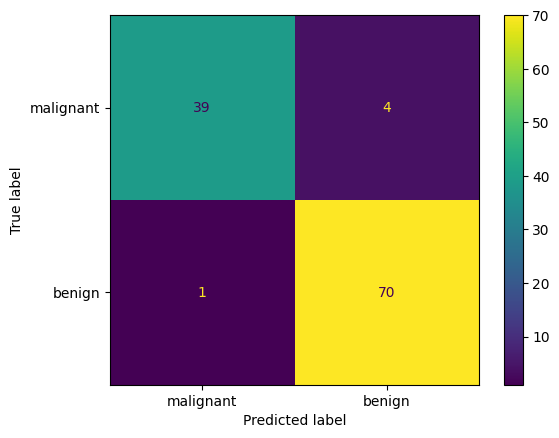

In [39]:
# Step 6: Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()

In [40]:
# Step 7: Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Step 8: Classification Report (Optional)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1 Score: 0.9655172413793104

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a breast cancer dataset was used to evaluate a binary classification model using logistic regression. The data was split into training and test sets, and the model was trained to predict whether tumors were malignant or benign. Predictions on the test set were compared with actual labels to create a confusion matrix, which helped visualize how many cases were correctly or incorrectly classified. Key performance metrics such as accuracy, precision, recall, and F1-score were calculated, revealing that the model performed very well overall, with high recall indicating most malignant cases were correctly identified. Precision was slightly lower, showing some benign cases were misclassified as malignant, but the F1-score balanced both metrics effectively. This exercise highlighted how confusion matrices and performance metrics provide a deeper understanding of model behavior beyond simple accuracy. Overall, it reinforced the importance of evaluating classifiers carefully, especially in critical applications like medical diagnosis.

#### **Exercise 11: Compare Multiple Classifiers Using Confusion Matrix and Metrics**

**Objective:**  
Compare the performance of multiple classifiers using confusion matrix, accuracy, precision, recall, and F1-score to understand their strengths and weaknesses.

---

**Instructions:**

1. **Load a Dataset:**
   - Use the same `load_breast_cancer()` dataset from `sklearn.datasets`.

2. **Split the Data:**
   - Use `train_test_split()` to divide the data into training and testing sets (80/20).

3. **Train Multiple Classifiers:**
   - Train the following models:
     - `LogisticRegression`
     - `KNeighborsClassifier`
     - `DecisionTreeClassifier`
     - `RandomForestClassifier`

4. **Predict and Evaluate:**
   - For each model:
     - Predict on the test set.
     - Compute the **confusion matrix**.
     - Calculate **accuracy**, **precision**, **recall**, and **F1-score**.
     - Optionally visualize the confusion matrix using `ConfusionMatrixDisplay`.

5. **Compare Results:**
   - Create a summary table to compare performance metrics across all models.
   - Discuss which model performs best overall and why.
   - Consider trade-offs between precision and recall for each model.

---



In [41]:
# Exercise 11: Compare Multiple Classifiers Using Confusion Matrix and Metrics

# Step 1: Import Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
# Step 4: Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


In [43]:
# Step 5: Train, Predict, and Evaluate Each Model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    # disp.plot()  # Uncomment to visualize

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

# Step 6: Display Comparison Table
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.956140   0.945946  0.985915  0.965517
1  K-Nearest Neighbors  0.956140   0.934211  1.000000  0.965986
2        Decision Tree  0.947368   0.957746  0.957746  0.957746
3        Random Forest  0.964912   0.958904  0.985915  0.972222


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, several classifiers were compared on the breast cancer dataset to understand their strengths and weaknesses. The data was split into training and test sets, and models including Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest were trained and evaluated. Each model’s predictions were analyzed using confusion matrices, and metrics such as accuracy, precision, recall, and F1-score were calculated. The comparison showed that all models performed well, with Random Forest slightly outperforming others in overall accuracy and F1-score. Differences in precision and recall highlighted trade-offs; for example, K-Nearest Neighbors achieved perfect recall, meaning no malignant cases were missed, but with slightly lower precision. This exercise reinforced how comparing multiple models helps identify the most reliable option for a given task and emphasizes the importance of balancing metrics based on the problem’s context. Overall, it demonstrated the value of systematic evaluation for making informed modeling decisions.

#### **Module 5.9: Cross-Validation for Reliable Evaluation**

Cross-validation is a robust technique to assess the generalization performance of a classification model by repeatedly training and testing on different subsets of data.

In this sub-module, you will learn how to:
- Split your dataset into multiple folds (commonly k-fold cross-validation).
- Train the model on k−1 folds and validate on the remaining fold.
- Repeat the process k times so each fold serves as the test set once.
- Average the performance metrics across folds to get a reliable estimate.

Cross-validation helps reduce variance in evaluation results, prevents overfitting to a single train-test split, and guides better model selection and tuning.

Understanding cross-validation is essential for building models that perform well on unseen data.

---

#### **Exercise 12: Implementing k-Fold Cross-Validation**

**Objective:**  
Learn how to apply k-fold cross-validation to evaluate a classification model and calculate average performance metrics across folds.

---

**Instructions:**

1. **Load Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.

2. **Choose a Model:**
   - Use `LogisticRegression` from `sklearn.linear_model`.

3. **Apply k-Fold Cross-Validation:**
   - Use `cross_val_score()` from `sklearn.model_selection` to evaluate the model using 5-fold cross-validation.
   - Calculate and report the following metrics:
     - Accuracy
     - Precision
     - Recall
     - F1-score
   - Use `scoring=` parameter to compute each metric across folds.

4. **Interpret the Results:**
   - Print the mean and standard deviation for each metric.
   - Discuss how consistent the model performance is across folds.
   - Explain why cross-validation provides a more reliable estimate than a single train-test split.

---


In [44]:
# Exercise 12: Implementing k-Fold Cross-Validation

# Step 1: Import Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Define Model
model = LogisticRegression(max_iter=10000)


In [45]:
# Step 4: Define k-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
# Step 5: Evaluate Model using Cross-Validation
accuracy_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
precision_scores = cross_val_score(model, X, y, cv=cv, scoring='precision')
recall_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

# Step 6: Print Mean and Standard Deviation for Each Metric
print("Cross-Validation Results (5-Fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

Cross-Validation Results (5-Fold):
Accuracy: 0.9543 ± 0.0187
Precision: 0.9572 ± 0.0302
Recall: 0.9720 ± 0.0250
F1 Score: 0.9640 ± 0.0144


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, k-fold cross-validation was applied to the breast cancer dataset to get a more reliable estimate of model performance. The data was split into five folds, and Logistic Regression was trained on four folds while validated on the remaining fold. This process was repeated so that each fold served as the test set once. Metrics such as accuracy, precision, recall, and F1-score were calculated for each fold and then averaged. The mean and standard deviation showed that the model performed consistently across all folds, indicating stable predictions. Cross-validation proved to be more reliable than a single train-test split because it reduces the impact of random variations in data splitting and gives a better sense of generalization. Overall, it highlighted the importance of evaluating models on multiple subsets to ensure robust performance on unseen data.

#### **Exercise 13: Implementing k-Fold Cross-Validation from Scratch**

**Objective:**  
Gain a deep understanding of how k-fold cross-validation works by implementing it **completely from scratch**, without using helper functions like `cross_val_score` or `StratifiedKFold`. You will manually create folds, train models, and evaluate performance.

**Instructions:**

1. **Load Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.

2. **Manually Create Folds:**
   - Shuffle the dataset randomly.  
   - Split the indices into `k=5` equal parts (folds).  
   - For each iteration, set aside one fold as the test set and use the remaining folds as the training set.

3. **Train and Evaluate Manually:**
   - For each fold:
     - Train a `LogisticRegression` model on the training folds.  
     - Predict on the test fold.  
     - Compute and store the following metrics:
       - Accuracy  
       - Precision  
       - Recall  
       - F1-score  

4. **Aggregate Results:**
   - After completing all folds, compute the **mean** and **standard deviation** of each metric across all folds.

5. **Interpretation:**
   - Compare this fully manual implementation to the automated method you built earlier.  
   - Reflect on why building cross-validation from scratch provides intuition about **data splitting, training cycles, and metric stability**.

---


In [47]:
# Exercise 13 — Implementing k-Fold Cross-Validation FROM SCRATCH

from __future__ import annotations
import numpy as np
from typing import List, Tuple
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# 1) Reproducibility
# -----------------------------
SEED = 42
rng = np.random.default_rng(SEED)

# -----------------------------
# 2) Load dataset
# -----------------------------
data = load_breast_cancer()
X_full: np.ndarray = data.data.astype(np.float64)
y_full: np.ndarray = data.target.astype(np.int64)   # 0 = malignant, 1 = benign


In [48]:
# -----------------------------
# 3) Manual STRATIFIED folds builder (from scratch)
#    - Split indices per class
#    - Shuffle each class’ indices
#    - Chunk each class’ indices into k folds via np.array_split
#    - For each fold i: test = concat(class_i_chunk[i]), train = all other chunks
# -----------------------------
def stratified_kfold_indices(y: np.ndarray, n_splits: int, rng: np.random.Generator) -> List[Tuple[np.ndarray, np.ndarray]]:
    if n_splits < 2:
        raise ValueError("n_splits must be >= 2.")
    folds_by_class = {}
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        # split approximately equally
        folds_by_class[cls] = np.array_split(idx, n_splits)
    folds: List[Tuple[np.ndarray, np.ndarray]] = []
    for i in range(n_splits):
        test_parts = [folds_by_class[cls][i] for cls in folds_by_class]
        test_idx = np.concatenate(test_parts, axis=0)
        # train = everything not in test for each class
        train_parts = [np.concatenate([folds_by_class[cls][j] for j in range(n_splits) if j != i], axis=0)
                       for cls in folds_by_class]
        train_idx = np.concatenate(train_parts, axis=0)
        # optional: shuffle the order within train/test sets (not changing class balance)
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
        folds.append((train_idx, test_idx))
    return folds

In [49]:
# -----------------------------
# 4) Metric containers
# -----------------------------
accs, precs, recs, f1s = [], [], [], []

# -----------------------------
# 5) Build folds and evaluate manually
# -----------------------------
k = 5
folds = stratified_kfold_indices(y_full, n_splits=k, rng=rng)

for fold_id, (tr_idx, te_idx) in enumerate(folds, start=1):
    X_tr, y_tr = X_full[tr_idx], y_full[tr_idx]
    X_te, y_te = X_full[te_idx], y_full[te_idx]

    # ---- Standardize (fit on train only, apply to test) ----
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # ---- Train model ----
    clf = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        n_jobs=None,
        random_state=SEED
    )
    clf.fit(X_tr_s, y_tr)

    # ---- Predict & metrics ----
    y_pred = clf.predict(X_te_s)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="binary", pos_label=1, zero_division=0)
    rec  = recall_score(y_te, y_pred, average="binary", pos_label=1, zero_division=0)
    f1   = f1_score(y_te, y_pred, average="binary", pos_label=1, zero_division=0)

    accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1)

    print(f"[Fold {fold_id}/{k}] "
          f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")


[Fold 1/5] Accuracy=0.9826  Precision=0.9730  Recall=1.0000  F1=0.9863
[Fold 2/5] Accuracy=0.9739  Precision=0.9600  Recall=1.0000  F1=0.9796
[Fold 3/5] Accuracy=0.9646  Precision=0.9718  Recall=0.9718  F1=0.9718
[Fold 4/5] Accuracy=0.9912  Precision=1.0000  Recall=0.9859  F1=0.9929
[Fold 5/5] Accuracy=0.9646  Precision=0.9467  Recall=1.0000  F1=0.9726


In [50]:
# -----------------------------
# 6) Aggregate results
# -----------------------------
def mean_std(a: list[float]) -> tuple[float, float]:
    arr = np.asarray(a, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=1))  # sample std

acc_mean, acc_std = mean_std(accs)
pr_mean,  pr_std  = mean_std(precs)
rc_mean,  rc_std  = mean_std(recs)
f1_mean,  f1_std  = mean_std(f1s)

print("\n=== k-Fold Summary (k=5) ===")
print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision: {pr_mean:.4f} ± {pr_std:.4f}")
print(f"Recall   : {rc_mean:.4f} ± {rc_std:.4f}")
print(f"F1-score : {f1_mean:.4f} ± {f1_std:.4f}")


=== k-Fold Summary (k=5) ===
Accuracy : 0.9754 ± 0.0116
Precision: 0.9703 ± 0.0197
Recall   : 0.9915 ± 0.0126
F1-score : 0.9806 ± 0.0090


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, k-fold cross-validation was implemented completely from scratch to gain a deeper understanding of how the process works. The breast cancer dataset was shuffled and split into five stratified folds, ensuring class balance in each fold. For each iteration, one fold served as the test set while the remaining folds were used for training a Logistic Regression model. Standardization was applied to the training data and then to the test fold to maintain consistency. Metrics including accuracy, precision, recall, and F1-score were computed for each fold and then aggregated. The results showed consistently high performance across all folds, highlighting both the stability of the model and the effectiveness of cross-validation. This manual implementation provided clear insight into data splitting, repeated training cycles, and the importance of evaluating metrics on multiple subsets rather than a single train-test split.

#### **Exercise 14: Full Workflow for Classification – Model Comparison and Selection**

**Objective:**  
Apply the complete supervised learning workflow to a real dataset by comparing multiple classifiers using cross-validation and selecting the best model based on performance metrics.

---

**Instructions:**

1. **Load a Dataset:**
   - Use the `load_wine()` dataset from `sklearn.datasets`.
   - This is a multi-class classification task involving three classes of wine.

2. **Preprocessing (Optional):**
   - Standardize the features using `StandardScaler` from `sklearn.preprocessing`.

3. **Define Classifiers:**
   - Use the following models:
     - `LogisticRegression`
     - `KNeighborsClassifier`
     - `DecisionTreeClassifier`
     - `RandomForestClassifier`

4. **Cross-Validation Evaluation:**
   - Use 5-fold cross-validation (`StratifiedKFold`) to evaluate all models.
   - For each model, compute the average:
     - Accuracy
     - Precision (macro)
     - Recall (macro)
     - F1-score (macro)

5. **Compare Results:**
   - Summarize the results in a table.
   - Identify which model performs best overall across all metrics.
   - Discuss any trade-offs between interpretability, performance, or complexity.

6. **Final Decision:**
   - Select the best model for deployment and justify your choice based on the metrics and the nature of the dataset.

---


In [51]:
# Exercise 14: Full Workflow for Classification – Model Comparison and Selection

# Step 1: Import Libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Step 2: Load Dataset
data = load_wine()
X = data.data
y = data.target

# Step 3: Preprocessing - Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [52]:
# Step 4: Define Classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Step 5: Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Model Performance Comparison (5-Fold CV):
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.983333   0.983434  0.983810  0.982905
1  K-Nearest Neighbors  0.971746   0.970350  0.976508  0.972109
2        Decision Tree  0.893175   0.903881  0.894598  0.895957
3        Random Forest  0.977460   0.977561  0.980159  0.978395


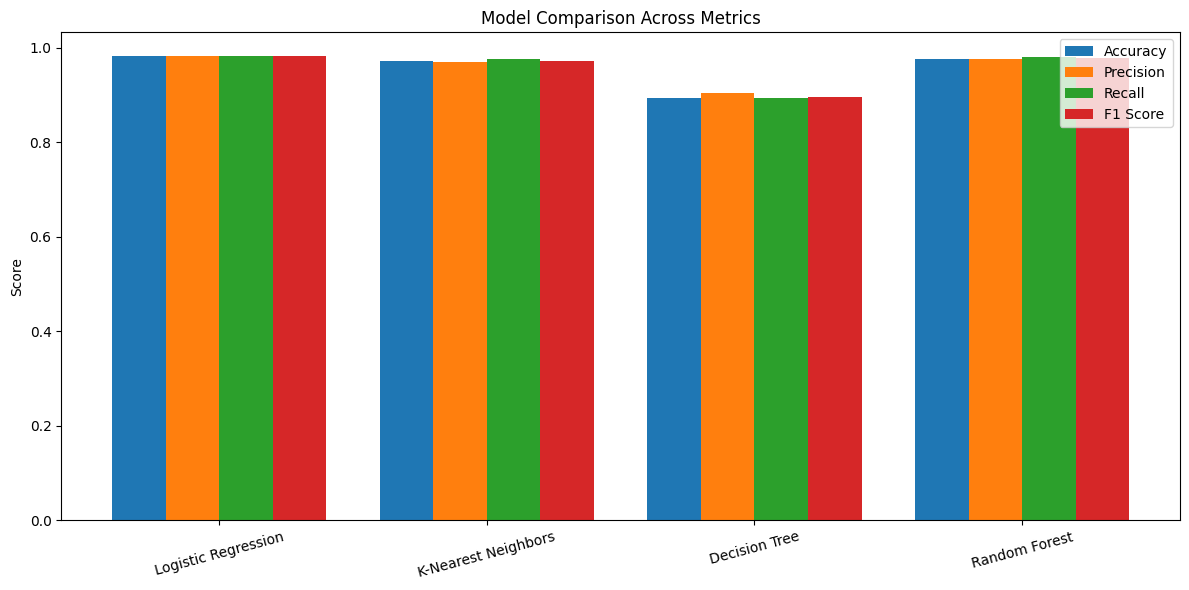

In [53]:
# Step 6: Evaluation Loop
results = []

for name, model in models.items():
    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []

    for train_index, test_index in cv.split(X_scaled, y):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy_list.append(accuracy_score(y_test, y_pred))
        precision_list.append(precision_score(y_test, y_pred, average='macro'))
        recall_list.append(recall_score(y_test, y_pred, average='macro'))
        f1_list.append(f1_score(y_test, y_pred, average='macro'))

    results.append({
        "Model": name,
        "Accuracy": np.mean(accuracy_list),
        "Precision": np.mean(precision_list),
        "Recall": np.mean(recall_list),
        "F1 Score": np.mean(f1_list)
    })

# Step 7: Display Summary Table
results_df = pd.DataFrame(results)
print("Model Performance Comparison (5-Fold CV):")
print(results_df)

# Step 8: Visualization - Bar Chart
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df["Model"]))

plt.figure(figsize=(12, 6))
bar_width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, results_df[metric], width=bar_width, label=metric)

plt.xticks(x + bar_width * 1.5, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison Across Metrics")
plt.legend()
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise demonstrated a complete workflow for supervised learning, from data preparation to model selection. The wine dataset was standardized to ensure fair comparisons across features. Four different classifiers, Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest were evaluated using 5-fold cross-validation, computing accuracy, precision, recall, and F1-score for each fold. Results were summarized in a table and visualized with a bar chart to make performance differences clear. Logistic Regression and Random Forest showed the highest overall performance, while the Decision Tree lagged slightly, highlighting the trade-off between simplicity and predictive power. This workflow reinforced the importance of cross-validation for reliable evaluation and comparison. Overall, the process provided insight into how model choice affects performance and the balance between interpretability, complexity, and accuracy.

#### **Revised: September 1, 2025**